# SCC0802 — Atividade 3

Leticia Barbanera (14588642), João Rissi Magnani (14582823)

In [1]:
# Instala somente pacotes que podem não estar disponíveis em um ambiente limpo.
import importlib.util
import subprocess
import sys

required_packages = {
    "kagglehub": "kagglehub",
    "transformers": "transformers",}

missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None]

if missing_packages:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        *missing_packages,])


In [2]:
from pathlib import Path
import random

import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, AutoModel, AutoProcessor

SEED = 75
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo usado: {device}")

Dispositivo usado: cpu


## 1. Preparação dos dados

O objetivo é deixar todo o ambiente pronto para a execução do trabalho de forma reprodutível. O dataset é baixado, os arquivos CSV são localizados e as tabelas principais são carregadas. Também são criados os caminhos completos das imagens e feita uma checagem para garantir que todos os arquivos esperados existem antes das próximas etapas.

In [3]:
#pega o dataset pelo KaggleHub e guarda o caminho local retornado.
dataset_path = Path(kagglehub.dataset_download("akinduhiman/urban-issues-dataset"))
print(f"Dataset baixado em: {dataset_path}")

Dataset baixado em: /Users/llbm/.cache/kagglehub/datasets/akinduhiman/urban-issues-dataset/versions/19


In [4]:
#uso arquivos locais que foram previamente criados 
def find_required_file(filename, search_roots):
    for root in search_roots:
        root = Path(root)
        direct_path = root / filename
        if direct_path.exists():
            return direct_path

        matches = list(root.rglob(filename)) if root.exists() else []
        if matches:
            return matches[0]

    raise FileNotFoundError(f"Arquivo obrigatório não encontrado: {filename}")

# search_roots = [Path.cwd(), dataset_path]

# gallery_csv = find_required_file("gallery.csv", search_roots)
# valid_queries_csv = find_required_file("valid_queries.csv", search_roots)
# test_queries_csv = find_required_file("test_queries.csv", search_roots)

import gdown

gallery_csv = "gallery.csv"
valid_queries_csv = "valid_queries.csv"
test_queries_csv = "test_queries.csv"

gdown.download("https://drive.google.com/uc?id=1BwgHAB3-xYrU4Q9vbilf6_Bq5NviJyAR", gallery_csv, quiet=False)
gdown.download("https://drive.google.com/uc?id=1HUie6gbLlUcf4VnB4H-yrv_2Z6qyw9uN", valid_queries_csv, quiet=False)
gdown.download("https://drive.google.com/uc?id=1io7cykPHHsP2AvCjJqwEH8ZdaM-CJz35", test_queries_csv, quiet=False)

print("CSVs encontrados:")
print("gallery:", gallery_csv)
print("valid_queries:", valid_queries_csv)
print("test_queries:", test_queries_csv)

CSVs encontrados:
gallery: /Users/llbm/Desktop/pcd/att3/gallery.csv
valid_queries: /Users/llbm/Desktop/pcd/att3/valid_queries.csv
test_queries: /Users/llbm/Desktop/pcd/att3/test_queries.csv


In [5]:
#carrega as tabelas antes de qualquer uso das variáveis.
gallery = pd.read_csv(gallery_csv)
valid_queries = pd.read_csv(valid_queries_csv)
test_queries = pd.read_csv(test_queries_csv)

print("Dimensões das tabelas:")
print("Gallery:", gallery.shape)
print("Validation queries:", valid_queries.shape)
print("Test queries:", test_queries.shape)

display(gallery.head())
display(valid_queries.head())
display(test_queries.head())

Dimensões das tabelas:
Gallery: (17679, 4)
Validation queries: (3775, 4)
Test queries: (3402, 3)


,gallery_id,image_id,relative_path,label_name
0,g_000000,train__000093_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
1,g_000001,train__000104_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
2,g_000002,train__000107_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
3,g_000003,train__000108_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
4,g_000004,train__000133_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures


,query_id,image_id,relative_path,label_name
0,v_000000,valid__000094_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
1,v_000001,valid__000145_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
2,v_000002,valid__000780_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
3,v_000003,valid__001053_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures
4,v_000004,valid__001055_jpg,Damaged concrete structures/Damaged concrete s...,Damaged concrete structures


,query_id,image_id,relative_path
0,t_000000,test__000100_jpg,Damaged concrete structures/Damaged concrete s...
1,t_000001,test__000144_jpg,Damaged concrete structures/Damaged concrete s...
2,t_000002,test__000791_jpg,Damaged concrete structures/Damaged concrete s...
3,t_000003,test__000795_jpg,Damaged concrete structures/Damaged concrete s...
4,t_000004,test__001062_jpg,Damaged concrete structures/Damaged concrete s...


In [6]:
#cria os caminhos absolutos das imagens e confere se todos os arquivos existem.
def add_image_path_column(df, base_path):
    df = df.copy()
    df["image_path"] = df["relative_path"].apply(lambda p: Path(base_path) / p)
    df["exists"] = df["image_path"].apply(lambda p: p.exists())
    return df

gallery = add_image_path_column(gallery, dataset_path)
valid_queries = add_image_path_column(valid_queries, dataset_path)
test_queries = add_image_path_column(test_queries, dataset_path)

for name, df in {
    "gallery": gallery,
    "valid_queries": valid_queries,
    "test_queries": test_queries,
}.items():
    print(f"{name}: {df['exists'].mean():.2%}")

if not gallery["exists"].all() or not valid_queries["exists"].all() or not test_queries["exists"].all():
    raise FileNotFoundError("Há imagens faltantes")

gallery: 100.00%
valid_queries: 100.00%
test_queries: 100.00%


## 2. Análise exploratória

Nesta etapa, é feita uma inspeção inicial dos dados para entender a estrutura das tabelas, as colunas disponíveis e a distribuição das classes. Essa análise é importante para verificar se os dados foram carregados corretamente e para identificar possíveis desbalanceamentos entre as classes. Além disso, algumas imagens são visualizadas como amostra, permitindo confirmar se os caminhos estão corretos e se os dados fazem sentido visualmente.

In [7]:
print("Colunas disponíveis:")
print("Gallery:", gallery.columns.tolist())
print("Valid queries:", valid_queries.columns.tolist())
print("Test queries:", test_queries.columns.tolist())

Colunas disponíveis:
Gallery: ['gallery_id', 'image_id', 'relative_path', 'label_name', 'image_path', 'exists']
Valid queries: ['query_id', 'image_id', 'relative_path', 'label_name', 'image_path', 'exists']
Test queries: ['query_id', 'image_id', 'relative_path', 'image_path', 'exists']



Distribuição de classes — Gallery:


label_name
Damaged concrete structures    8684
Potholes and RoadCracks        2575
Garbage                        2455
Graffitti                      1496
DamagedElectricalPoles         1304
FallenTrees                     887
DamagedRoadSigns                233
DeadAnimalsPollution             27
IllegalParking                   18
Name: count, dtype: int64

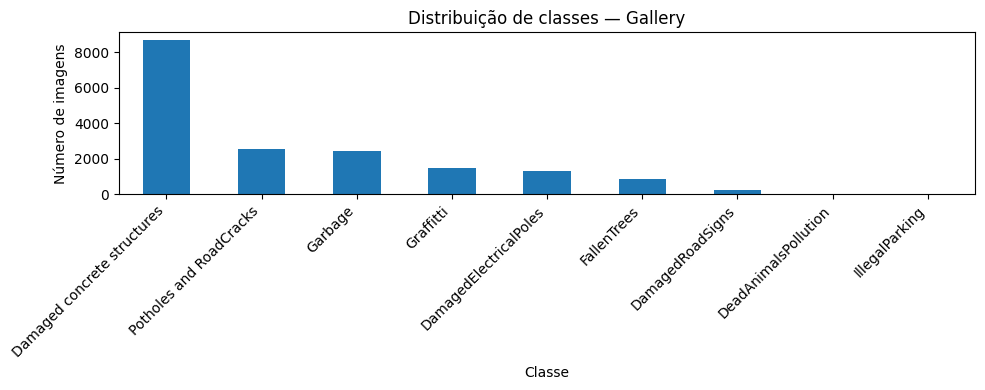


Distribuição de classes — Valid queries:


label_name
Damaged concrete structures    1199
Potholes and RoadCracks        1105
Garbage                         524
DamagedElectricalPoles          420
FallenTrees                     276
Graffitti                       205
DamagedRoadSigns                 36
DeadAnimalsPollution              8
IllegalParking                    2
Name: count, dtype: int64

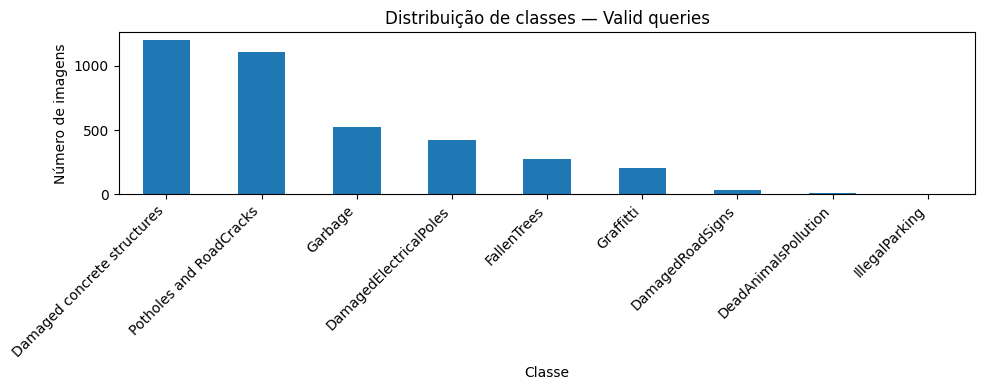

In [8]:
#distribuição de classes nas bases rotuladas.
for name, df in {"Gallery": gallery, "Valid queries": valid_queries}.items():
    if "label_name" in df.columns:
        class_counts = df["label_name"].value_counts()
        print(f"\nDistribuição de classes — {name}:")
        display(class_counts)

        class_counts.plot(kind="bar", figsize=(10, 4), title=f"Distribuição de classes — {name}")
        plt.xlabel("Classe")
        plt.ylabel("Número de imagens")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()


,gallery_prop,valid_prop
label_name,,
Damaged concrete structures,0.491204,0.317616
DamagedElectricalPoles,0.073760,0.111258
DamagedRoadSigns,0.013179,0.009536
DeadAnimalsPollution,0.001527,0.002119
FallenTrees,0.050173,0.073113
Garbage,0.138865,0.138808
Graffitti,0.084620,0.054305
IllegalParking,0.001018,0.000530
Potholes and RoadCracks,0.145653,0.292715


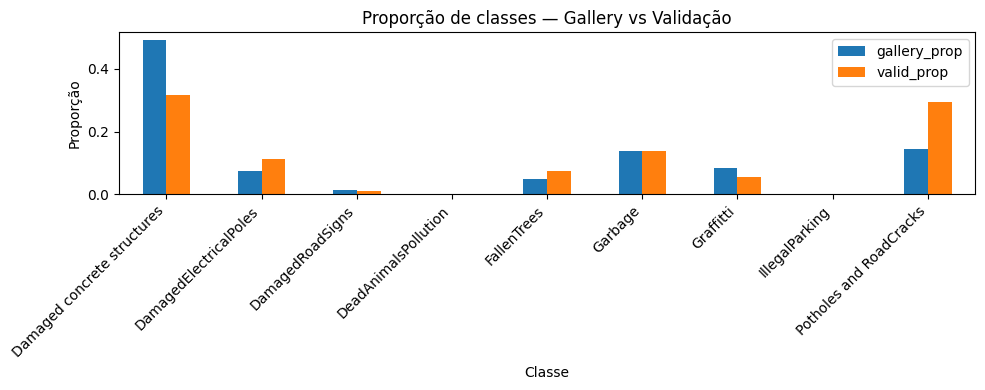

In [9]:
#compara a proporção das classes entre galeria e validação.
if "label_name" in gallery.columns and "label_name" in valid_queries.columns:
    class_dist = pd.DataFrame({
        "gallery_prop": gallery["label_name"].value_counts(normalize=True),
        "valid_prop": valid_queries["label_name"].value_counts(normalize=True),
    }).fillna(0)

    display(class_dist)

    class_dist.plot(kind="bar", figsize=(10, 4), title="Proporção de classes — Gallery vs Validação")
    plt.xlabel("Classe")
    plt.ylabel("Proporção")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

Resumo das dimensões das imagens:


,width,height,aspect_ratio
count,300.000000,300.000000,300.000000
mean,656.146667,642.446667,1.023439
std,396.337461,375.172425,0.124147
min,195.000000,168.000000,0.661765
25%,640.000000,640.000000,1.000000
50%,640.000000,640.000000,1.000000
75%,640.000000,640.000000,1.000000
max,4000.000000,4160.000000,1.785714


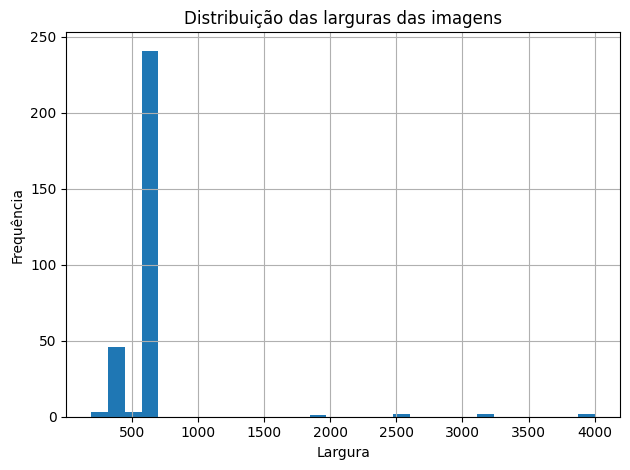

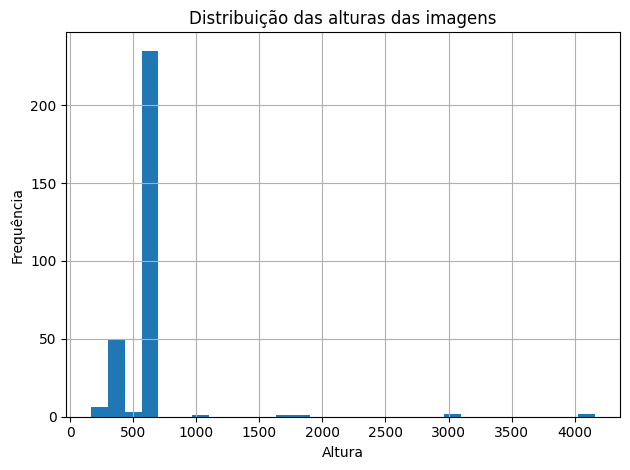

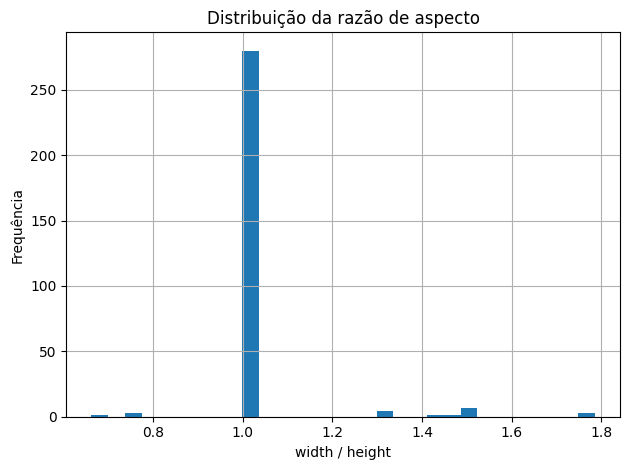

In [10]:
#amostra fixa para analisar dimensões
def get_image_size(path):
    try:
        with Image.open(path) as img:
            return img.size  # (largura, altura)
    except Exception:
        return None

sample_gallery = gallery.sample(min(300, len(gallery)), random_state=SEED).copy()
sample_gallery["image_size"] = sample_gallery["image_path"].apply(get_image_size)
sample_gallery = sample_gallery.dropna(subset=["image_size"])

sample_gallery["width"] = sample_gallery["image_size"].apply(lambda size: size[0])
sample_gallery["height"] = sample_gallery["image_size"].apply(lambda size: size[1])
sample_gallery["aspect_ratio"] = sample_gallery["width"] / sample_gallery["height"]

print("Resumo das dimensões das imagens:")
display(sample_gallery[["width", "height", "aspect_ratio"]].describe())

for column, title, xlabel in [
    ("width", "Distribuição das larguras das imagens", "Largura"),
    ("height", "Distribuição das alturas das imagens", "Altura"),
    ("aspect_ratio", "Distribuição da razão de aspecto", "width / height"),
]:
    sample_gallery[column].hist(bins=30)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

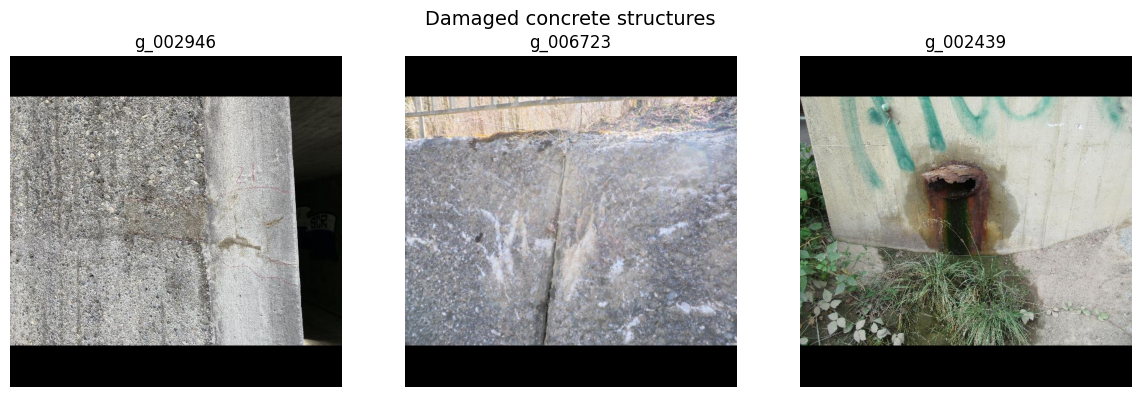

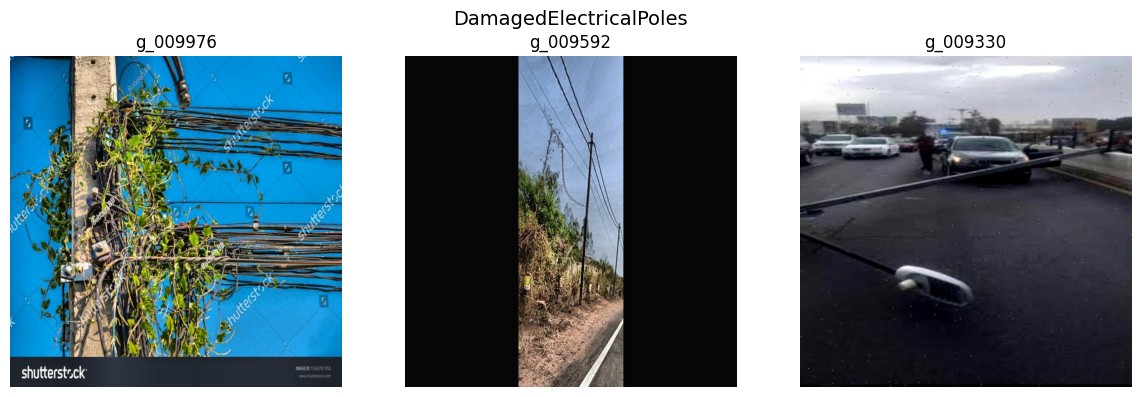

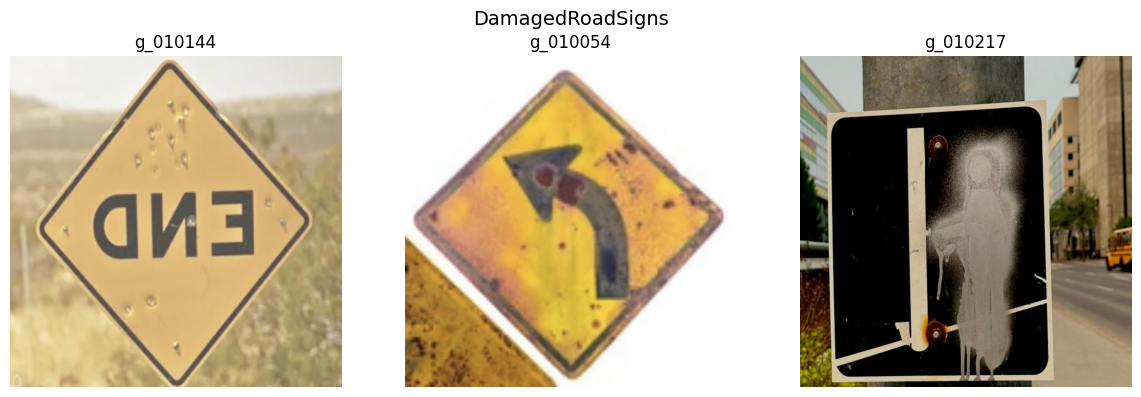

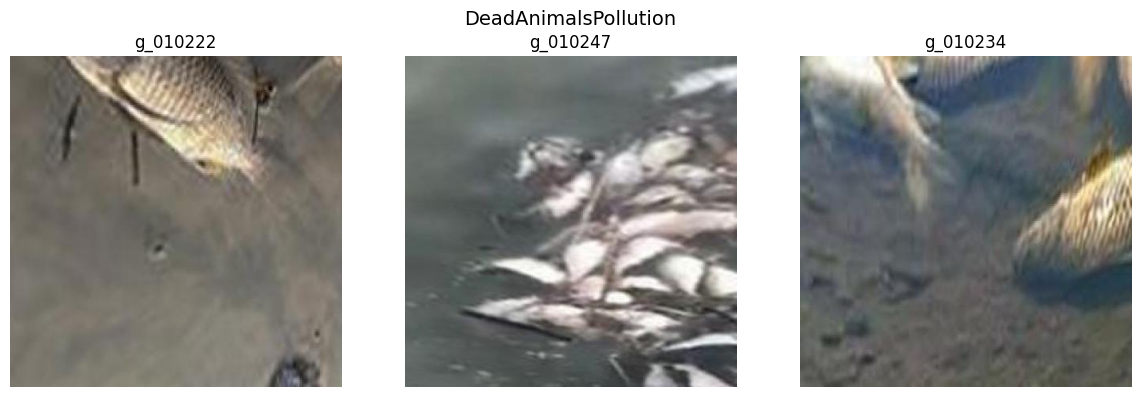

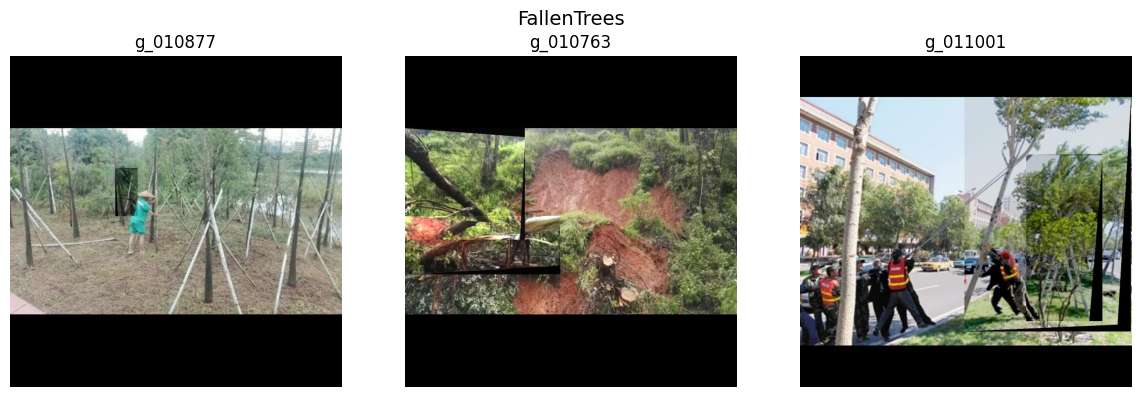

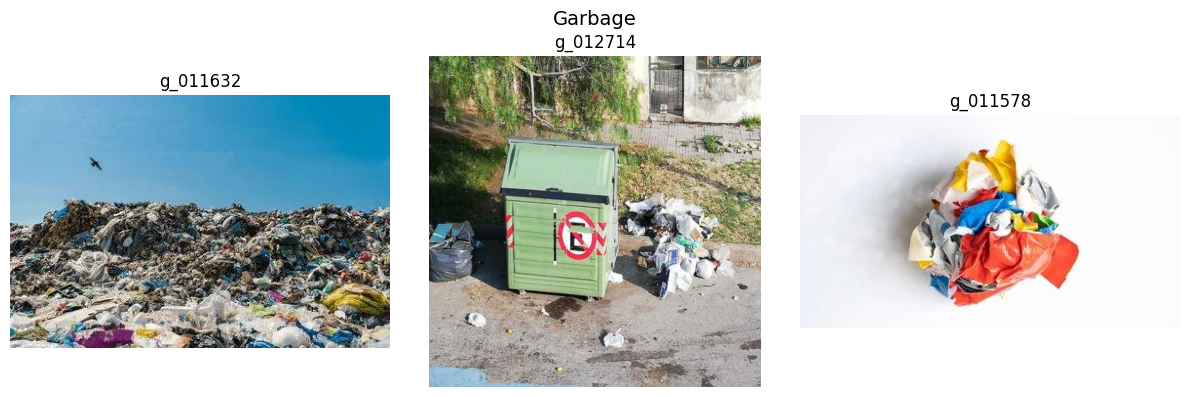

In [11]:
#alguns exemplos das classes
def show_examples_by_class(df, label_col="label_name", n_per_class=3, max_classes=6):
    classes = sorted(df[label_col].dropna().unique())[:max_classes]

    for cls in classes:
        subset = df[df[label_col] == cls].sample(
            min(n_per_class, len(df[df[label_col] == cls])),
            random_state=SEED,)
        fig, axes = plt.subplots(1, len(subset), figsize=(4 * len(subset), 4))
        if len(subset) == 1:
            axes = [axes]
        fig.suptitle(cls, fontsize=14)
        for ax, (_, row) in zip(axes, subset.iterrows()):
            with Image.open(row["image_path"]) as img:
                ax.imshow(img.convert("RGB"))
            ax.axis("off")
            ax.set_title(row.get("gallery_id", row.get("query_id", "")))
        plt.tight_layout()
        plt.show()

if "label_name" in gallery.columns:
    show_examples_by_class(gallery, label_col="label_name", n_per_class=3, max_classes=6)

## 3. Métrica avaliativa

Aqui, é definida a métrica usada para avaliar o desempenho do sistema. Como orientado, foi utilizada a métrica MAP@10, que considera tanto a presença de imagens corretas entre os dez primeiros resultados quanto a posição em que elas aparecem. Assim, o modelo é recompensado quando coloca resultados relevantes mais próximos do topo do ranking.

In [12]:
#a métrica usada é MAP@10.
#para cada query, recupera 10 imagens da galeria.
#Um resultado é relevante quando a classe da imagem recuperada é igual à classe correta da query.
def apk(actual_label, predicted_labels, k=10):
    predicted_labels = predicted_labels[:k]
    score = 0.0
    num_hits = 0.0
    for i, pred_label in enumerate(predicted_labels):
        if pred_label == actual_label:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    return score / k


def mapk(actual_labels, predicted_labels_list, k=10):
    scores = [
        apk(actual_label, predicted_labels, k=k)
        for actual_label, predicted_labels in zip(actual_labels, predicted_labels_list)]
    return float(np.mean(scores))


def evaluate_retrieval_mapk(valid_queries, gallery, predictions_df, k=10):
    gallery_label_map = dict(zip(gallery["gallery_id"].astype(str), gallery["label_name"]))
    query_label_map = dict(zip(valid_queries["query_id"], valid_queries["label_name"]))
    actual_labels = []
    predicted_labels_list = []
    for _, row in predictions_df.iterrows():
        query_id = row["query_id"]
        predicted_gallery_ids = str(row["predictions"]).split()[:k]
        actual_label = query_label_map[query_id]
        predicted_labels = [gallery_label_map[str(gallery_id)] for gallery_id in predicted_gallery_ids]
        actual_labels.append(actual_label)
        predicted_labels_list.append(predicted_labels)

    return mapk(actual_labels, predicted_labels_list, k=k)

## 4. Extração de embeddings

Nesta etapa, as imagens são transformadas em embeddings usando modelos pré-treinados. Esses vetores representam visualmente cada imagem em um espaço multidimensional, permitindo comparar consultas e imagens da galeria por similaridade. Os embeddings são salvos em arquivos para evitar recomputações desnecessárias, tornando o notebook mais eficiente e reprodutível em execuções futuras.

In [13]:
embeddings_dir = Path("embeddings")
embeddings_dir.mkdir(exist_ok=True)

BATCH_SIZE = 64
NUM_WORKERS = 0
FORCE_RECOMPUTE_EMBEDDINGS = False

In [14]:
class ImageRetrievalDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        return {"image": image, "idx": idx}


def make_collate_fn(processor):
    def collate_fn(batch):
        images = [item["image"] for item in batch]
        indices = [item["idx"] for item in batch]
        inputs = processor(images=images, return_tensors="pt")
        return inputs, indices
    return collate_fn


def load_embeddings(path):
    data = np.load(path, allow_pickle=True)
    return data["ids"], data["embeddings"]

In [15]:
@torch.no_grad()
def extract_dinov2_embeddings(df, id_col, output_path, processor, model):
    if output_path.exists() and not FORCE_RECOMPUTE_EMBEDDINGS:
        print(f"Carregando embeddings existentes: {output_path}")
        return load_embeddings(output_path)

    dataset = ImageRetrievalDataset(df)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=make_collate_fn(processor),)

    all_embeddings = []
    all_ids = []

    for inputs, indices in tqdm(loader):
        inputs = {key: value.to(device) for key, value in inputs.items()}
        outputs = model(**inputs)
        #DINOv2: usa o token CLS como representação global da imagem
        embeddings = outputs.last_hidden_state[:, 0, :]
        embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        all_embeddings.append(embeddings.cpu().numpy())
        all_ids.extend(df.iloc[indices][id_col].tolist())
    all_embeddings = np.vstack(all_embeddings)
    np.savez_compressed(output_path, ids=np.array(all_ids), embeddings=all_embeddings)

    print(f"Salvo em: {output_path}")
    print("Shape dos embeddings:", all_embeddings.shape)
    return np.array(all_ids), all_embeddings

In [16]:
@torch.no_grad()
def extract_siglip_embeddings(df, id_col, output_path, processor, model):
    if output_path.exists() and not FORCE_RECOMPUTE_EMBEDDINGS:
        print(f"Carregando embeddings existentes: {output_path}")
        return load_embeddings(output_path)

    dataset = ImageRetrievalDataset(df)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        collate_fn=make_collate_fn(processor),)

    all_embeddings = []
    all_ids = []
    for inputs, indices in tqdm(loader):
        inputs = {key: value.to(device) for key, value in inputs.items()}
        #SigLIP: get_image_features retorna diretamente o embedding visual.
        embeddings = model.get_image_features(**inputs)
        embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        all_embeddings.append(embeddings.detach().cpu().numpy())
        all_ids.extend(df.iloc[indices][id_col].tolist())

    all_embeddings = np.vstack(all_embeddings)
    np.savez_compressed(output_path, ids=np.array(all_ids), embeddings=all_embeddings)

    print(f"Salvo em: {output_path}")
    print("Shape dos embeddings:", all_embeddings.shape)
    return np.array(all_ids), all_embeddings

### 4.1. DINOv2

O DINOv2 é baseado em Vision Transformers e aprende representações auto-supervisionadas. Durante o treinamento, diferentes versões aumentadas da mesma imagem são passadas por uma rede “aluno” e uma rede “professor”, e o objetivo é fazer com que o aluno produza representações consistentes com as do professor. Assim, o modelo aprende invariâncias visuais sem depender de rótulos. Neste trabalho, uso o vetor final do encoder como embedding da imagem e comparo esses embeddings por similaridade.

In [17]:
DINOV2_MODEL_NAME = "facebook/dinov2-base"

dinov2_processor = AutoImageProcessor.from_pretrained(DINOV2_MODEL_NAME)
dinov2_model = AutoModel.from_pretrained(DINOV2_MODEL_NAME).to(device)
dinov2_model.eval()

print("Modelo carregado:", DINOV2_MODEL_NAME)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Modelo carregado: facebook/dinov2-base


In [18]:
dinov2_gallery_ids, dinov2_gallery_embeddings = extract_dinov2_embeddings(
    df=gallery,
    id_col="gallery_id",
    output_path=embeddings_dir / "dinov2_gallery_embeddings.npz",
    processor=dinov2_processor,
    model=dinov2_model,)

dinov2_valid_query_ids, dinov2_valid_query_embeddings = extract_dinov2_embeddings(
    df=valid_queries,
    id_col="query_id",
    output_path=embeddings_dir / "dinov2_valid_query_embeddings.npz",
    processor=dinov2_processor,
    model=dinov2_model,)

dinov2_test_query_ids, dinov2_test_query_embeddings = extract_dinov2_embeddings(
    df=test_queries,
    id_col="query_id",
    output_path=embeddings_dir / "dinov2_test_query_embeddings.npz",
    processor=dinov2_processor,
    model=dinov2_model,)

Carregando embeddings existentes: embeddings/dinov2_gallery_embeddings.npz
Carregando embeddings existentes: embeddings/dinov2_valid_query_embeddings.npz
Carregando embeddings existentes: embeddings/dinov2_test_query_embeddings.npz


### 4.2. SigLIP

O SigLIP segue a ideia de modelos imagem-texto, com um encoder visual e um encoder textual treinados contrastivamente. A diferença principal em relação ao CLIP clássico é que ele usa uma loss sigmoid independente para pares imagem-texto, em vez de uma softmax global sobre o batch. Isso permite aprender associações imagem-texto de forma mais flexível. Aqui, uso apenas o encoder visual para gerar embeddings das imagens, aproveitando o espaço semântico aprendido durante esse treinamento multimodal.

In [19]:
SIGLIP_MODEL_NAME = "google/siglip-base-patch16-224"

siglip_processor = AutoProcessor.from_pretrained(SIGLIP_MODEL_NAME)
siglip_model = AutoModel.from_pretrained(SIGLIP_MODEL_NAME).to(device)
siglip_model.eval()

print("Modelo carregado:", SIGLIP_MODEL_NAME)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Modelo carregado: google/siglip-base-patch16-224


In [20]:
siglip_gallery_ids, siglip_gallery_embeddings = extract_siglip_embeddings(
    df=gallery,
    id_col="gallery_id",
    output_path=embeddings_dir / "siglip_gallery_embeddings.npz",
    processor=siglip_processor,
    model=siglip_model,)

siglip_valid_query_ids, siglip_valid_query_embeddings = extract_siglip_embeddings(
    df=valid_queries,
    id_col="query_id",
    output_path=embeddings_dir / "siglip_valid_query_embeddings.npz",
    processor=siglip_processor,
    model=siglip_model,)

siglip_test_query_ids, siglip_test_query_embeddings = extract_siglip_embeddings(
    df=test_queries,
    id_col="query_id",
    output_path=embeddings_dir / "siglip_test_query_embeddings.npz",
    processor=siglip_processor,
    model=siglip_model,)

Carregando embeddings existentes: embeddings/siglip_gallery_embeddings.npz
Carregando embeddings existentes: embeddings/siglip_valid_query_embeddings.npz
Carregando embeddings existentes: embeddings/siglip_test_query_embeddings.npz


## 5. Recuperação baseada em similaridade

Então, os embeddings das imagens de consulta são comparados com os embeddings da galeria usando similaridade cosseno. Como os vetores foram normalizados, essa comparação pode ser feita por produto interno. Para cada consulta, são selecionadas as dez imagens mais similares da galeria, formando as predições que serão avaliadas pela métrica MAP@10.

In [21]:
def generate_retrieval_predictions(query_ids, query_embeddings, gallery_ids, gallery_embeddings, k=10):
    #como os embeddings foram normalizados, o produto interno equivale à similaridade cosseno.
    similarity_matrix = query_embeddings @ gallery_embeddings.T
    topk_indices = np.argsort(-similarity_matrix, axis=1)[:, :k]

    predictions = []
    for i, query_id in enumerate(query_ids):
        top_gallery_ids = gallery_ids[topk_indices[i]]
        predictions.append({
            "query_id": query_id,
            "predictions": " ".join(map(str, top_gallery_ids)),})

    return pd.DataFrame(predictions)


dinov2_valid_predictions = generate_retrieval_predictions(
    query_ids=dinov2_valid_query_ids,
    query_embeddings=dinov2_valid_query_embeddings,
    gallery_ids=dinov2_gallery_ids,
    gallery_embeddings=dinov2_gallery_embeddings,
    k=10,)

siglip_valid_predictions = generate_retrieval_predictions(
    query_ids=siglip_valid_query_ids,
    query_embeddings=siglip_valid_query_embeddings,
    gallery_ids=siglip_gallery_ids,
    gallery_embeddings=siglip_gallery_embeddings,
    k=10,)

display(siglip_valid_predictions.head())

,query_id,predictions
0,v_000000,g_000014 g_000005 g_000002 g_000033 g_000003 g...
1,v_000001,g_000056 g_000136 g_000069 g_000070 g_000078 g...
2,v_000002,g_000074 g_000204 g_000018 g_001385 g_000150 g...
3,v_000003,g_000077 g_000001 g_000005 g_000078 g_000033 g...
4,v_000004,g_000074 g_000033 g_001385 g_000001 g_000018 g...


## 6. Comparação de desempenho geral

Aqui são comparados os desempenhos gerais dos modelos testados na base de validação. Essa comparação permite identificar qual abordagem produz melhores rankings de imagens de forma global.

,model,MAP@10
1,SigLIP,0.956083
0,DINOv2,0.951894


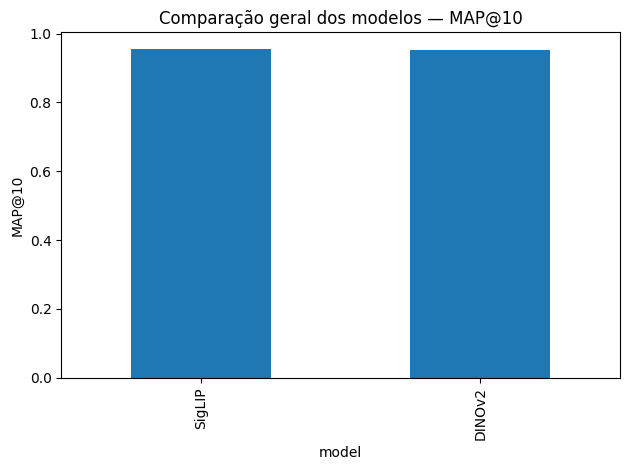

In [22]:
models_predictions = {
    "DINOv2": dinov2_valid_predictions,
    "SigLIP": siglip_valid_predictions,}

results = []
for model_name, predictions_df in models_predictions.items():
    score = evaluate_retrieval_mapk(valid_queries, gallery, predictions_df, k=10)
    results.append({"model": model_name, "MAP@10": score})
results_df = pd.DataFrame(results).sort_values(by="MAP@10", ascending=False)
display(results_df)

results_df.plot(x="model", y="MAP@10", kind="bar", legend=False, title="Comparação geral dos modelos — MAP@10")
plt.ylabel("MAP@10")
plt.tight_layout()
plt.show()

## 7. Comparação de desempenho por classe

Também, o desempenho é analisado separadamente para cada classe. Essa avaliação é importante porque a média geral pode esconder classes em que o modelo tem dificuldade. Essa etapa foi particularmente importante em versões anteriores do notebook, nas quais comparamos mais modelos além de Dinov2 e Siglip. Ao observar os resultados por classe, é possível entender melhor os pontos fortes e fracos da abordagem e verificar se o modelo está funcionando de maneira equilibrada entre os diferentes tipos de problema urbano. Além disso, conseguimos ter uma ideia de boas "combinações" de modelos. 

model,DINOv2,SigLIP
label,,
Damaged concrete structures,0.986979,0.997093
DamagedElectricalPoles,0.890215,0.914973
DamagedRoadSigns,0.910435,0.780655
DeadAnimalsPollution,0.749950,0.873750
FallenTrees,0.850827,0.838125
Garbage,0.973228,0.978001
Graffitti,0.787568,0.763088
IllegalParking,0.839444,0.445833
Potholes and RoadCracks,0.985896,0.989318


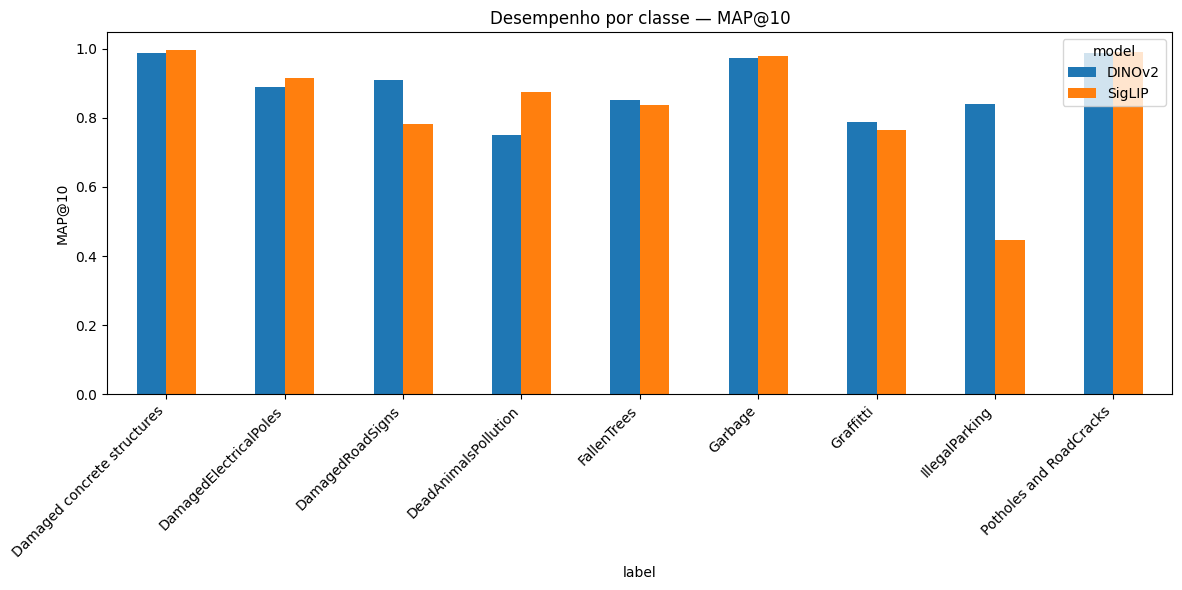

In [23]:
def evaluate_mapk_per_class(valid_queries, gallery, predictions_df, k=10):
    gallery_label_map = dict(zip(gallery["gallery_id"].astype(str), gallery["label_name"]))
    query_label_map = dict(zip(valid_queries["query_id"], valid_queries["label_name"]))

    rows = []
    for _, row in predictions_df.iterrows():
        query_id = row["query_id"]
        predicted_gallery_ids = str(row["predictions"]).split()[:k]
        actual_label = query_label_map[query_id]
        predicted_labels = [gallery_label_map[str(g_id)] for g_id in predicted_gallery_ids]
        rows.append({
            "query_id": query_id,
            "label": actual_label,
            "ap": apk(actual_label, predicted_labels, k=k),})

    return (
        pd.DataFrame(rows)
        .groupby("label", as_index=False)["ap"]
        .mean()
        .rename(columns={"ap": "MAP@10"}))

per_class_results = []
for model_name, predictions_df in models_predictions.items():
    per_class_df = evaluate_mapk_per_class(valid_queries, gallery, predictions_df, k=10)
    per_class_df["model"] = model_name
    per_class_results.append(per_class_df)
per_class_results_df = pd.concat(per_class_results, ignore_index=True)
pivot_df = per_class_results_df.pivot(index="label", columns="model", values="MAP@10")

display(pivot_df)

pivot_df.plot(kind="bar", figsize=(12, 6), title="Desempenho por classe — MAP@10")
plt.ylabel("MAP@10")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Ensemble e re-ranking por pseudo-classe

Os resultados dos modelos são combinados num ensemble usando uma média ponderada das matrizes de similaridade. A ideia é aproveitar informações complementares dos embeddings gerados por modelos diferentes. Além disso, é aplicado um re-ranking baseado em pseudo-classe, que tenta priorizar imagens cuja classe estimada seja mais coerente com a consulta, melhorando a ordenação final dos resultados.

In [24]:
def ensemble_similarity_matrix(query_emb_a, gallery_emb_a, query_emb_b, gallery_emb_b, alpha=0.7):
    sim_a = query_emb_a @ gallery_emb_a.T
    sim_b = query_emb_b @ gallery_emb_b.T
    return alpha * sim_a + (1 - alpha) * sim_b


def predictions_from_similarity_matrix(query_ids, gallery_ids, similarity_matrix, k=10):
    topk_indices = np.argsort(-similarity_matrix, axis=1)[:, :k]
    predictions = []
    for i, query_id in enumerate(query_ids):
        top_gallery_ids = gallery_ids[topk_indices[i]]
        predictions.append({
            "query_id": query_id,
            "predictions": " ".join(map(str, top_gallery_ids)),})

    return pd.DataFrame(predictions)

In [25]:
#busca simples do melhor peso do ensemble na validação.
ensemble_results = []
alpha_values = np.round(np.linspace(0, 1, 11), 2)

for alpha in alpha_values:
    valid_similarity_matrix = ensemble_similarity_matrix(
        query_emb_a=siglip_valid_query_embeddings,
        gallery_emb_a=siglip_gallery_embeddings,
        query_emb_b=dinov2_valid_query_embeddings,
        gallery_emb_b=dinov2_gallery_embeddings,
        alpha=alpha,)

    ensemble_valid_predictions = predictions_from_similarity_matrix(
        query_ids=siglip_valid_query_ids,
        gallery_ids=siglip_gallery_ids,
        similarity_matrix=valid_similarity_matrix,
        k=10,)

    score = evaluate_retrieval_mapk(valid_queries, gallery, ensemble_valid_predictions, k=10)
    ensemble_results.append({"alpha_siglip": alpha, "MAP@10": score})

ensemble_results_df = pd.DataFrame(ensemble_results).sort_values(by="MAP@10", ascending=False)
display(ensemble_results_df)

,alpha_siglip,MAP@10
7,0.7,0.966599
8,0.8,0.966516
6,0.6,0.965240
5,0.5,0.964093
9,0.9,0.963779
4,0.4,0.962523
3,0.3,0.960701
2,0.2,0.957887
10,1.0,0.956083
1,0.1,0.954618


In [26]:
def generate_pseudoclass_rerank_predictions(
    query_ids,
    gallery_ids,
    similarity_matrix,
    gallery,
    pseudo_top_k=20,
    rerank_pool_k=50,
    final_k=10,
    min_confidence=0.7,):
    gallery_label_map = dict(zip(gallery["gallery_id"].astype(str), gallery["label_name"]))
    predictions = []

    for i, query_id in enumerate(query_ids):
        scores = similarity_matrix[i]
        ranked_idx = np.argsort(-scores)
        ranked_gallery_ids = gallery_ids[ranked_idx]

        #estima uma pseudo-classe a partir dos primeiros resultados recuperados.
        pseudo_pool = ranked_gallery_ids[:pseudo_top_k]
        pseudo_labels = [gallery_label_map[str(g_id)] for g_id in pseudo_pool]
        label_counts = pd.Series(pseudo_labels).value_counts()
        pseudo_class = label_counts.index[0]
        confidence = label_counts.iloc[0] / pseudo_top_k

        rerank_pool = ranked_gallery_ids[:rerank_pool_k]
        if confidence >= min_confidence:
            same_class = [g_id for g_id in rerank_pool if gallery_label_map[str(g_id)] == pseudo_class]
            other_class = [g_id for g_id in rerank_pool if gallery_label_map[str(g_id)] != pseudo_class]
            reranked_gallery_ids = same_class + other_class
        else:
            reranked_gallery_ids = list(rerank_pool)

        final_gallery_ids = reranked_gallery_ids[:final_k]
        predictions.append({
            "query_id": query_id,
            "predictions": " ".join(map(str, final_gallery_ids)),
            "pseudo_class": pseudo_class,
            "confidence": confidence,
            "rerank_applied": confidence >= min_confidence,})

    return pd.DataFrame(predictions)

In [27]:
BEST_ALPHA = ensemble_results_df.iloc[0]["alpha_siglip"]

valid_similarity_matrix = ensemble_similarity_matrix(
    query_emb_a=siglip_valid_query_embeddings,
    gallery_emb_a=siglip_gallery_embeddings,
    query_emb_b=dinov2_valid_query_embeddings,
    gallery_emb_b=dinov2_gallery_embeddings,
    alpha=BEST_ALPHA,)

rerank_results = []
thresholds = [0.68, 0.69, 0.7, 0.71, 0.72]

for threshold in thresholds:
    preds_with_info = generate_pseudoclass_rerank_predictions(
        query_ids=siglip_valid_query_ids,
        gallery_ids=siglip_gallery_ids,
        similarity_matrix=valid_similarity_matrix,
        gallery=gallery,
        pseudo_top_k=20,
        rerank_pool_k=50,
        final_k=10,
        min_confidence=threshold,)

    preds = preds_with_info[["query_id", "predictions"]]
    score = evaluate_retrieval_mapk(valid_queries, gallery, preds, k=10)

    rerank_results.append({
        "min_confidence": threshold,
        "MAP@10": score,
        "rerank_applied_rate": preds_with_info["rerank_applied"].mean(),})

rerank_results_df = pd.DataFrame(rerank_results).sort_values(by="MAP@10", ascending=False)
display(rerank_results_df)

,min_confidence,MAP@10,rerank_applied_rate
0,0.68,0.975422,0.977219
1,0.69,0.975422,0.977219
2,0.70,0.975422,0.977219
3,0.71,0.974380,0.969007
4,0.72,0.974380,0.969007


## 9. Geração do arquivo final de submissão

Por fim, a melhor configuração encontrada na validação é aplicada ao conjunto de teste. São geradas as dez imagens mais relevantes para cada consulta e os resultados são organizados no formato esperado para submissão no kaggle.

In [28]:
BEST_THRESHOLD = rerank_results_df.iloc[0]["min_confidence"]

test_similarity_matrix = ensemble_similarity_matrix(
    query_emb_a=siglip_test_query_embeddings,
    gallery_emb_a=siglip_gallery_embeddings,
    query_emb_b=dinov2_test_query_embeddings,
    gallery_emb_b=dinov2_gallery_embeddings,
    alpha=BEST_ALPHA,)

ensemble_rerank_test_predictions_info = generate_pseudoclass_rerank_predictions(
    query_ids=siglip_test_query_ids,
    gallery_ids=siglip_gallery_ids,
    similarity_matrix=test_similarity_matrix,
    gallery=gallery,
    pseudo_top_k=20,
    rerank_pool_k=50,
    final_k=10,
    min_confidence=BEST_THRESHOLD,)

ensemble_rerank_test_predictions = ensemble_rerank_test_predictions_info[["query_id", "predictions"]]
ensemble_rerank_test_predictions = test_queries[["query_id"]].merge(
    ensemble_rerank_test_predictions,
    on="query_id",
    how="left",)

submission_path = Path("submission_ensemble_siglip_dinov2_pseudoclass_rerank.csv")
ensemble_rerank_test_predictions.to_csv(submission_path, index=False)

print(f"Arquivo salvo em: {submission_path}")
print("BEST_ALPHA:", BEST_ALPHA)
print("BEST_THRESHOLD:", BEST_THRESHOLD)
print("Formato da submissão:", ensemble_rerank_test_predictions.shape)
display(ensemble_rerank_test_predictions.head())

Arquivo salvo em: submission_ensemble_siglip_dinov2_pseudoclass_rerank.csv
BEST_ALPHA: 0.7
BEST_THRESHOLD: 0.68
Formato da submissão: (3402, 2)


,query_id,predictions
0,t_000000,g_000001 g_000033 g_000142 g_000078 g_000158 g...
1,t_000001,g_000032 g_000035 g_000043 g_000139 g_000033 g...
2,t_000002,g_000078 g_000144 g_000014 g_000147 g_000033 g...
3,t_000003,g_000142 g_000002 g_000033 g_000078 g_000073 g...
4,t_000004,g_000020 g_000141 g_001377 g_000122 g_001389 g...
